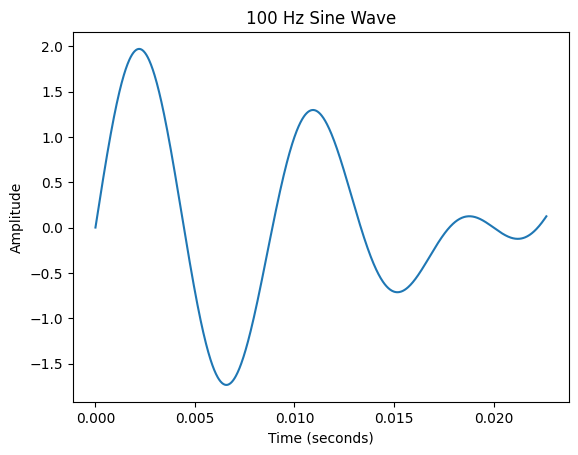

In [20]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 44100       # 44,100 samples per second
duration = 1              # 1 second
frequency = 440           # 100 Hz

t = np.arange(0, duration, 1 / sample_rate)

signal = (
    np.sin(2 * np.pi * 100 * t)
    + np.sin(0.5 * np.pi * 500 * t)
)

plt.plot(t[:1000], signal[:1000])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("100 Hz Sine Wave")
plt.show()

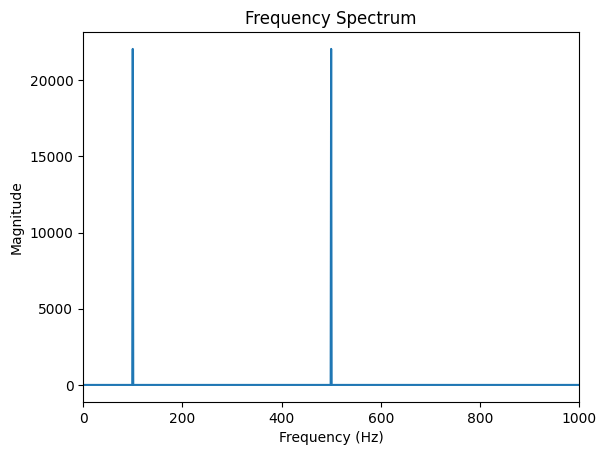

In [16]:
fft = np.fft.fft(signal)

frequencies = np.fft.fftfreq(
    len(signal),
    1 / sample_rate
)

magnitude = np.abs(fft)

# Only keep positive frequencies
positive = frequencies >= 0

frequencies = frequencies[positive]
magnitude = magnitude[positive]

plt.plot(frequencies, magnitude)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")

plt.xlim(0, 1000)

plt.show()

In [21]:
fft = np.fft.rfft(signal)

frequencies = np.fft.rfftfreq(
    len(signal),
    d=1 / sample_rate
)

magnitude = np.abs(fft)

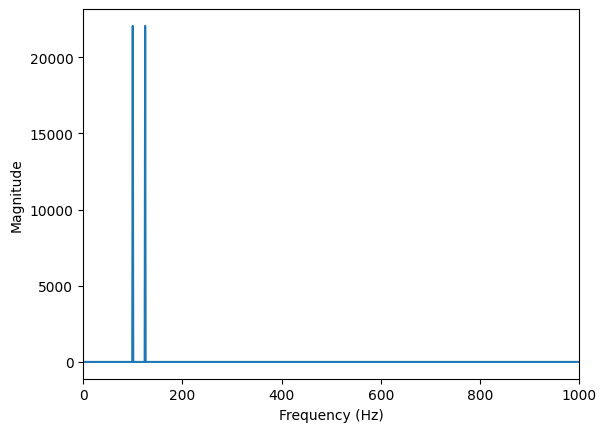

In [22]:
plt.plot(frequencies, magnitude)
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [ ]:
!pipx install scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

sample_rate = 44100
duration = 3

t = np.arange(
    0,
    duration,
    1 / sample_rate
)

# First second: 200 Hz
# Second second: 500 Hz
# Third second: 1000 Hz

signal = np.zeros_like(t)

signal[0 * sample_rate : 1 * sample_rate] = \
    np.sin(2 * np.pi * 200 * t[0 * sample_rate : 1 * sample_rate])

signal[1 * sample_rate : 2 * sample_rate] = \
    np.sin(2 * np.pi * 500 * t[1 * sample_rate : 2 * sample_rate])

signal[2 * sample_rate : 3 * sample_rate] = \
    np.sin(2 * np.pi * 1000 * t[2 * sample_rate : 3 * sample_rate])

frequencies, times, Sxx = spectrogram(
    signal,
    fs=sample_rate
)

plt.pcolormesh(
    times,
    frequencies,
    10 * np.log10(Sxx + 1e-10)
)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (seconds)")
plt.ylim(0, 2000)
plt.title("Spectrogram")

plt.show()